In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import random



manualSeed = 999
print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)

Random Seed:  999


In [ ]:
num_classes = 7
batch_size = 64
learning_rate = 0.001

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

train_transforms = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

eval_transforms = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

data_dir = "C:\\Users\\Ilmu Komputer\\OneDrive\\Desktop\\uas_etprof\\dataset\\train"
test_dir = "C:\\Users\\Ilmu Komputer\\OneDrive\\Desktop\\uas_etprof\\dataset\\test"

if not os.path.exists(data_dir):
    raise FileNotFoundError(f"Path dataset tidak ditemukan: {data_dir}")
if not os.path.exists(data_dir):
    raise FileNotFoundError(f"Path dataset tidak ditemukan: {test_dir}")

full_dataset = datasets.ImageFolder(root=data_dir)
test_dataset = datasets.ImageFolder(root=test_dir, transform=eval_transforms)

num_samples = len(full_dataset)
train_size = int(0.875 * num_samples)
val_size = num_samples - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_dataset.dataset.transform = train_transforms
val_dataset.dataset.transform = eval_transforms

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

Using device: cuda


In [ ]:
class CustomResNet18(nn.Module):
    def __init__(self, num_classes):
        super(CustomResNet18, self).__init__()
        self.resnet = models.resnet18(pretrained=True)
        self.in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Identity()
        self.fc = nn.Linear(self.in_features, num_classes)

    def forward(self, x):
        features = self.resnet(x)
        return self.fc(features)

resnet = CustomResNet18(num_classes=num_classes).to(device)


class CustomEfficientNetB0(nn.Module):
    def __init__(self, num_classes):
        super(CustomEfficientNetB0, self).__init__()
        self.efficientnet = models.efficientnet_b0(pretrained=True)
        self.in_features = self.efficientnet.classifier[1].in_features
        self.efficientnet.classifier[1] = nn.Identity()
        self.fc = nn.Linear(self.in_features, num_classes)

    def forward(self, x):
        features = self.efficientnet(x)
        return self.fc(features)

efficientnet = CustomEfficientNetB0(num_classes=num_classes).to(device)


class CustomMobileNetV2(nn.Module):
    def __init__(self, num_classes):
        super(CustomMobileNetV2, self).__init__()
        self.mobilenet = models.mobilenet_v2(pretrained=True)
        self.in_features = self.mobilenet.classifier[1].in_features
        self.mobilenet.classifier[1] = nn.Identity()
        self.fc = nn.Linear(self.in_features, num_classes)

    def forward(self, x):
        features = self.mobilenet(x)
        return self.fc(features)

mobilenet = CustomMobileNetV2(num_classes=num_classes).to(device)

c:\conda\miniconda3\envs\torch_env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\conda\miniconda3\envs\torch_env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
c:\conda\miniconda3\envs\torch_env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNe

In [ ]:
def train_model_dynamic(model, criterion, optimizer, train_loader, val_loader, patience=0, model_name="model"):
    print("Model's classifier:", model.fc if hasattr(model, 'fc') else "No fc found")

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    epoch = 0
    best_train_loss = 0
    best_valid_loss = 0
    best_train_accuracy = 0
    best_valid_accuracy = 0
    best_epoch = 0

    best_val_loss = float('inf')
    no_improve_count = 0

    best_val_loss = float('inf')
    no_improve_count = 0
    frozen = True

    for param in model.parameters():
        param.requires_grad = False
    for param in model.module.fc.parameters() if hasattr(model, 'module') else model.fc.parameters():
        param.requires_grad = True

    while True:
        epoch += 1
        print(f"Epoch {epoch} {'[Frozen]' if frozen else '[Unfrozen]'}")

        model.train()
        train_loss, correct, total = 0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total
        train_losses.append(train_loss / len(train_loader))
        train_accs.append(train_acc)

        val_loss, correct, total = 0, 0, 0
        model.eval()
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_acc = correct / total
        val_losses.append(val_loss / len(val_loader))
        val_accs.append(val_acc)

        print(f"Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, "
              f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            no_improve_count = 0
            torch.save(model.state_dict(), model_name)
            print("Model terbaik terbaru adalah pada epoch ke:", epoch)
            best_train_loss = train_loss / len(train_loader)
            best_valid_loss = val_loss / len(val_loader)
            best_train_accuracy = train_acc
            best_valid_accuracy = val_acc
            best_epoch = epoch
        else:
            no_improve_count += 1

        if no_improve_count >= patience and frozen:
            print("Unfreezing model backbone...")
            for param in model.parameters():
                param.requires_grad = True
            frozen = False
            no_improve_count = 0
            optimizer = optim.AdamW(model.parameters(), lr=1e-4)

        if no_improve_count >= patience and not frozen:
            print("Early stopping triggered.")
            break

    return model, train_losses, val_losses, train_accs, val_accs, best_train_loss, best_valid_loss, best_train_accuracy, best_valid_accuracy, best_epoch

In [ ]:
def test(model, test_loader, model_name="model"):
    # Validation
    all_preds, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        cm = confusion_matrix(all_labels, all_preds)
        plt.figure(figsize=(8, 6))

        class_labels = ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.title(f"Confusion Matrix - {model_name}")
        plt.show()

        print(classification_report(all_labels, all_preds, target_names=class_labels,labels=list(range(len(class_labels))), zero_division=0))


Training ResNet-18...
Model's classifier: Linear(in_features=512, out_features=7, bias=True)
Epoch 1 [Frozen]
Train Loss: 1.6151, Val Loss: 1.5549, Train Acc: 0.3661, Val Acc: 0.3943
Model terbaik terbaru adalah pada epoch ke: 1
Epoch 2 [Frozen]
Train Loss: 1.4969, Val Loss: 1.5165, Train Acc: 0.4256, Val Acc: 0.4138
Model terbaik terbaru adalah pada epoch ke: 2
Epoch 3 [Frozen]
Train Loss: 1.4613, Val Loss: 1.5273, Train Acc: 0.4420, Val Acc: 0.4207
Epoch 4 [Frozen]
Train Loss: 1.4435, Val Loss: 1.5057, Train Acc: 0.4472, Val Acc: 0.4266
Model terbaik terbaru adalah pada epoch ke: 4
Epoch 5 [Frozen]
Train Loss: 1.4379, Val Loss: 1.4546, Train Acc: 0.4569, Val Acc: 0.4388
Model terbaik terbaru adalah pada epoch ke: 5
Epoch 6 [Frozen]
Train Loss: 1.4256, Val Loss: 1.4571, Train Acc: 0.4573, Val Acc: 0.4408
Epoch 7 [Frozen]
Train Loss: 1.4198, Val Loss: 1.4463, Train Acc: 0.4582, Val Acc: 0.4500
Model terbaik terbaru adalah pada epoch ke: 7
Epoch 8 [Frozen]
Train Loss: 1.4150, Val Loss:

C:\Users\Ilmu Komputer\AppData\Local\Temp\ipykernel_42760\2385630966.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


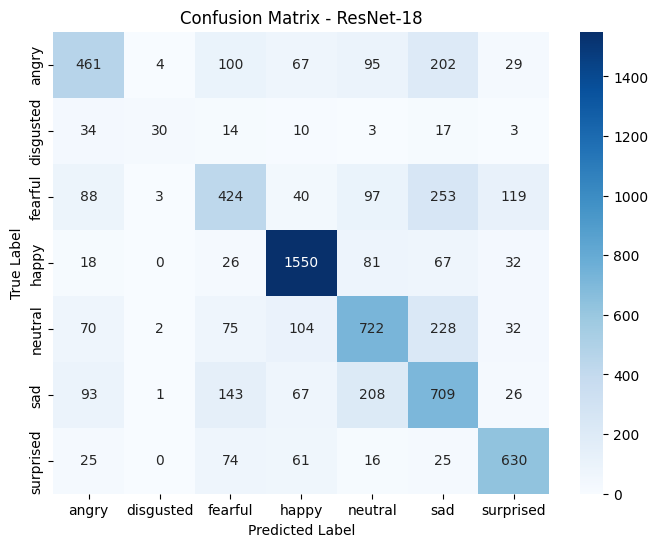

              precision    recall  f1-score   support

       angry       0.58      0.48      0.53       958
   disgusted       0.75      0.27      0.40       111
     fearful       0.50      0.41      0.45      1024
       happy       0.82      0.87      0.84      1774
     neutral       0.59      0.59      0.59      1233
         sad       0.47      0.57      0.52      1247
   surprised       0.72      0.76      0.74       831

    accuracy                           0.63      7178
   macro avg       0.63      0.56      0.58      7178
weighted avg       0.63      0.63      0.63      7178



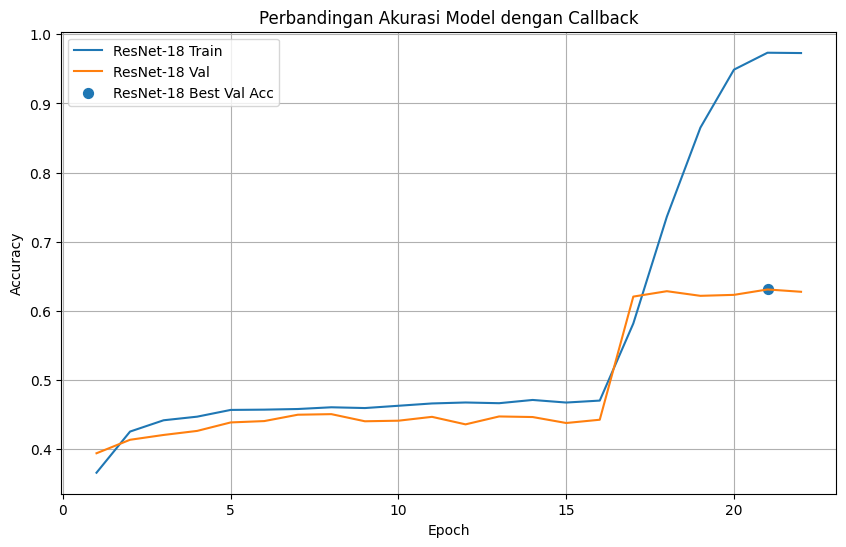

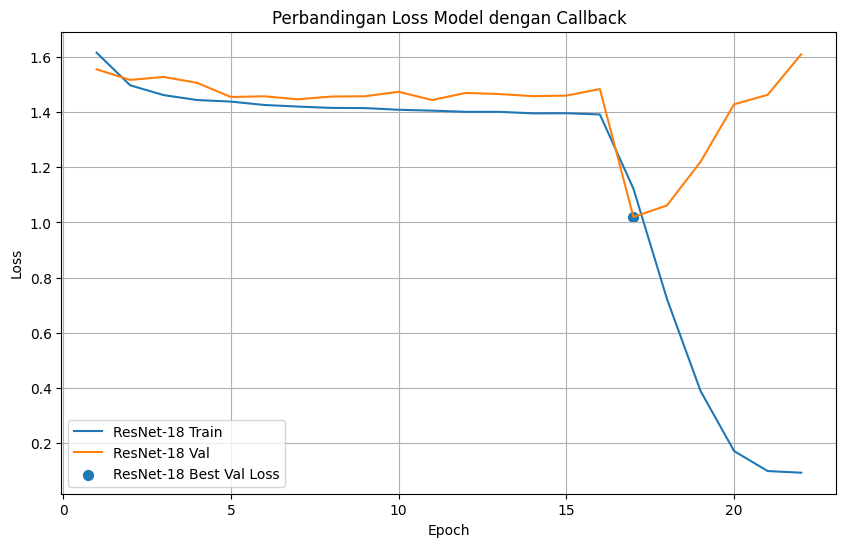


Training EfficientNet-B0...
Model's classifier: Linear(in_features=1280, out_features=7, bias=True)
Epoch 1 [Frozen]
Train Loss: 1.5928, Val Loss: 1.5089, Train Acc: 0.3764, Val Acc: 0.4202
Model terbaik terbaru adalah pada epoch ke: 1
Epoch 2 [Frozen]
Train Loss: 1.4976, Val Loss: 1.4732, Train Acc: 0.4247, Val Acc: 0.4310
Model terbaik terbaru adalah pada epoch ke: 2
Epoch 3 [Frozen]
Train Loss: 1.4688, Val Loss: 1.4715, Train Acc: 0.4346, Val Acc: 0.4394
Model terbaik terbaru adalah pada epoch ke: 3
Epoch 4 [Frozen]
Train Loss: 1.4607, Val Loss: 1.4603, Train Acc: 0.4434, Val Acc: 0.4452
Model terbaik terbaru adalah pada epoch ke: 4
Epoch 5 [Frozen]
Train Loss: 1.4459, Val Loss: 1.4707, Train Acc: 0.4488, Val Acc: 0.4514
Epoch 6 [Frozen]
Train Loss: 1.4400, Val Loss: 1.4351, Train Acc: 0.4477, Val Acc: 0.4533
Model terbaik terbaru adalah pada epoch ke: 6
Epoch 7 [Frozen]
Train Loss: 1.4349, Val Loss: 1.4379, Train Acc: 0.4512, Val Acc: 0.4489
Epoch 8 [Frozen]
Train Loss: 1.4330, Va

C:\Users\Ilmu Komputer\AppData\Local\Temp\ipykernel_42760\2385630966.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


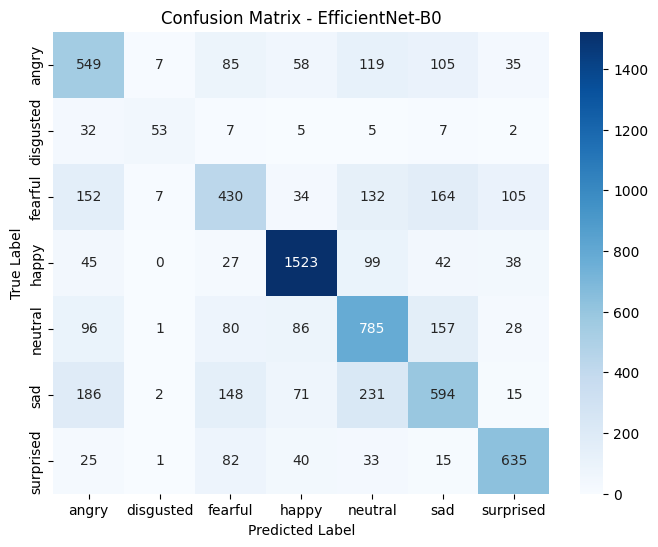

              precision    recall  f1-score   support

       angry       0.51      0.57      0.54       958
   disgusted       0.75      0.48      0.58       111
     fearful       0.50      0.42      0.46      1024
       happy       0.84      0.86      0.85      1774
     neutral       0.56      0.64      0.60      1233
         sad       0.55      0.48      0.51      1247
   surprised       0.74      0.76      0.75       831

    accuracy                           0.64      7178
   macro avg       0.63      0.60      0.61      7178
weighted avg       0.63      0.64      0.63      7178



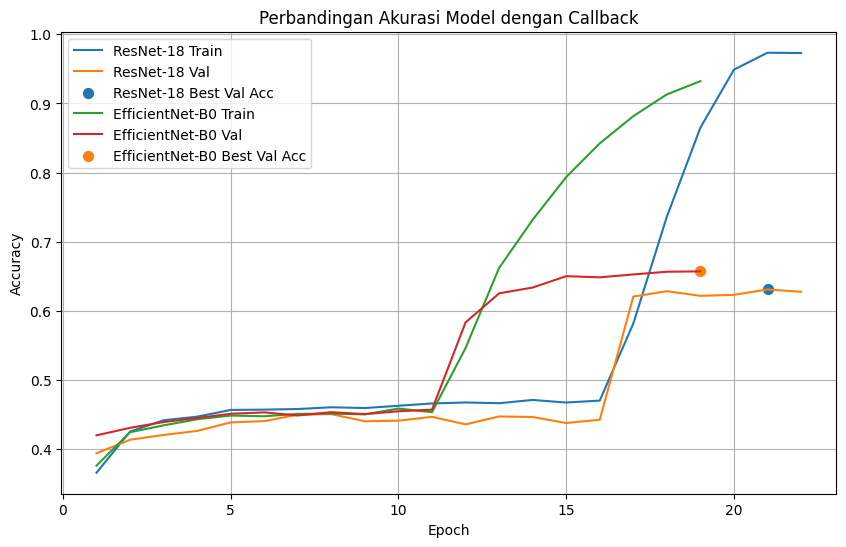

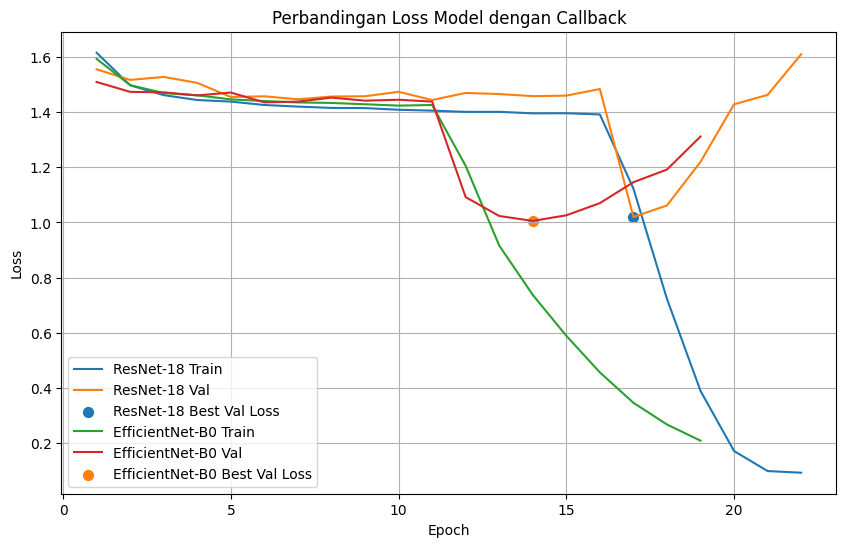


Training MobileNetV2...
Model's classifier: Linear(in_features=1280, out_features=7, bias=True)
Epoch 1 [Frozen]
Train Loss: 1.6037, Val Loss: 1.5104, Train Acc: 0.3725, Val Acc: 0.4174
Model terbaik terbaru adalah pada epoch ke: 1
Epoch 2 [Frozen]
Train Loss: 1.5070, Val Loss: 1.4666, Train Acc: 0.4214, Val Acc: 0.4405
Model terbaik terbaru adalah pada epoch ke: 2
Epoch 3 [Frozen]
Train Loss: 1.4910, Val Loss: 1.4805, Train Acc: 0.4258, Val Acc: 0.4388
Epoch 4 [Frozen]
Train Loss: 1.4825, Val Loss: 1.4888, Train Acc: 0.4317, Val Acc: 0.4274
Epoch 5 [Frozen]
Train Loss: 1.4844, Val Loss: 1.4487, Train Acc: 0.4305, Val Acc: 0.4452
Model terbaik terbaru adalah pada epoch ke: 5
Epoch 6 [Frozen]
Train Loss: 1.4719, Val Loss: 1.4683, Train Acc: 0.4357, Val Acc: 0.4405
Epoch 7 [Frozen]
Train Loss: 1.4798, Val Loss: 1.4401, Train Acc: 0.4313, Val Acc: 0.4430
Model terbaik terbaru adalah pada epoch ke: 7
Epoch 8 [Frozen]
Train Loss: 1.4736, Val Loss: 1.4494, Train Acc: 0.4351, Val Acc: 0.4525

C:\Users\Ilmu Komputer\AppData\Local\Temp\ipykernel_42760\2385630966.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


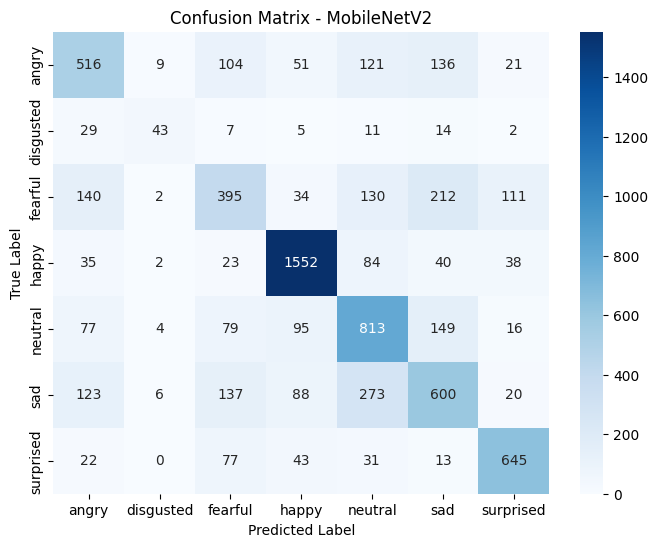

              precision    recall  f1-score   support

       angry       0.55      0.54      0.54       958
   disgusted       0.65      0.39      0.49       111
     fearful       0.48      0.39      0.43      1024
       happy       0.83      0.87      0.85      1774
     neutral       0.56      0.66      0.60      1233
         sad       0.52      0.48      0.50      1247
   surprised       0.76      0.78      0.77       831

    accuracy                           0.64      7178
   macro avg       0.62      0.59      0.60      7178
weighted avg       0.63      0.64      0.63      7178



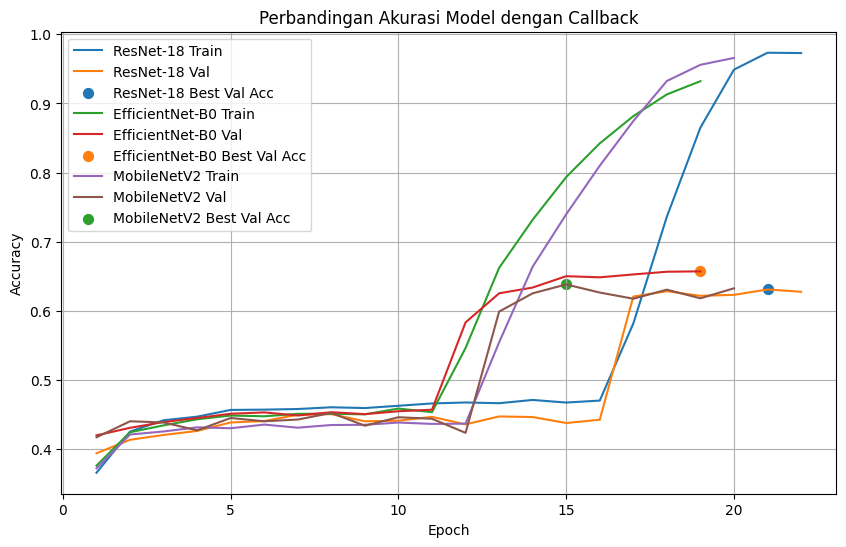

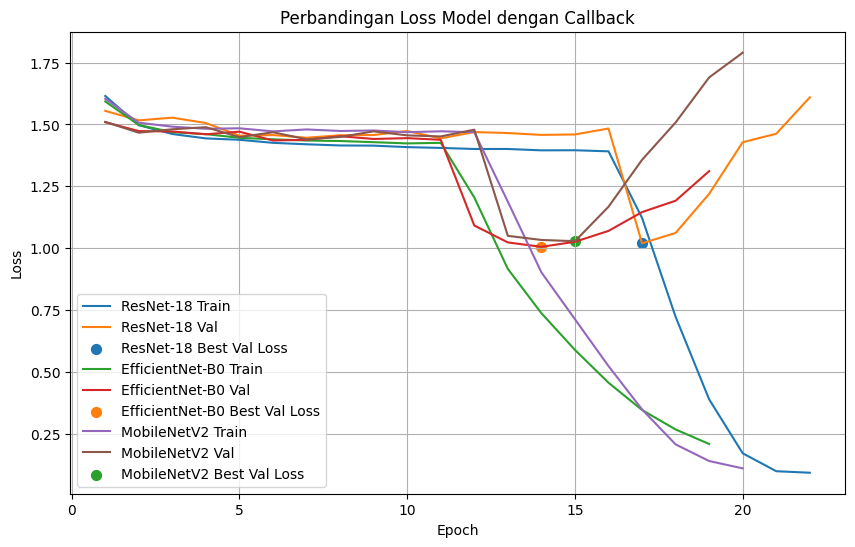

In [ ]:
results = {}

for model_name, model in zip(["ResNet-18", "EfficientNet-B0", "MobileNetV2"],
                             [resnet, efficientnet, mobilenet]):
    print(f"\nTraining {model_name}...")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    model, train_losses, val_losses, train_accs, val_accs, best_train_loss, best_valid_loss, best_train_accuracy, best_valid_accuracy, best_epoch = train_model_dynamic(
    model, criterion, optimizer, train_loader, val_loader, patience=5, model_name=model_name)


    results[model_name] = {
        "train_accs": train_accs,
        "val_accs": val_accs,
        "train_losses": train_losses,
        "val_losses": val_losses
        }


    print("=== Best Training Results ===")
    print(f"Best Epoch          : {best_epoch}")
    print(f"Best Train Loss     : {best_train_loss}")
    print(f"Best Valid Loss     : {best_valid_loss}")
    print(f"Best Train Accuracy : {100*best_train_accuracy:.2f}%")
    print(f"Best Valid Accuracy : {100*best_valid_accuracy:.2f}%")


    best_model_path = f"{model_name}"
    model.load_state_dict(torch.load(best_model_path))
    test(model, test_loader, model_name=model_name)


    plt.figure(figsize=(10, 6))
    for model_name in results:
        train_accs = results[model_name]["train_accs"]
        val_accs = results[model_name]["val_accs"]
        epochs = range(1, len(train_accs) + 1)

        plt.plot(epochs, train_accs, label=f"{model_name} Train")
        plt.plot(epochs, val_accs, label=f"{model_name} Val")

        best_val_acc_epoch = val_accs.index(max(val_accs)) + 1
        best_val_acc = max(val_accs)

        plt.scatter(best_val_acc_epoch, best_val_acc, label=f"{model_name} Best Val Acc", s=50)

    plt.title("Perbandingan Akurasi Model dengan Callback")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 6))
    for model_name in results:
        train_losses = results[model_name]["train_losses"]
        val_losses = results[model_name]["val_losses"]
        epochs = range(1, len(train_losses) + 1)

        plt.plot(epochs, train_losses, label=f"{model_name} Train")
        plt.plot(epochs, val_losses, label=f"{model_name} Val")

        best_val_loss_epoch = val_losses.index(min(val_losses)) + 1
        best_val_loss = min(val_losses)

        plt.scatter(best_val_loss_epoch, best_val_loss, label=f"{model_name} Best Val Loss", s=50)

    plt.title("Perbandingan Loss Model dengan Callback")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


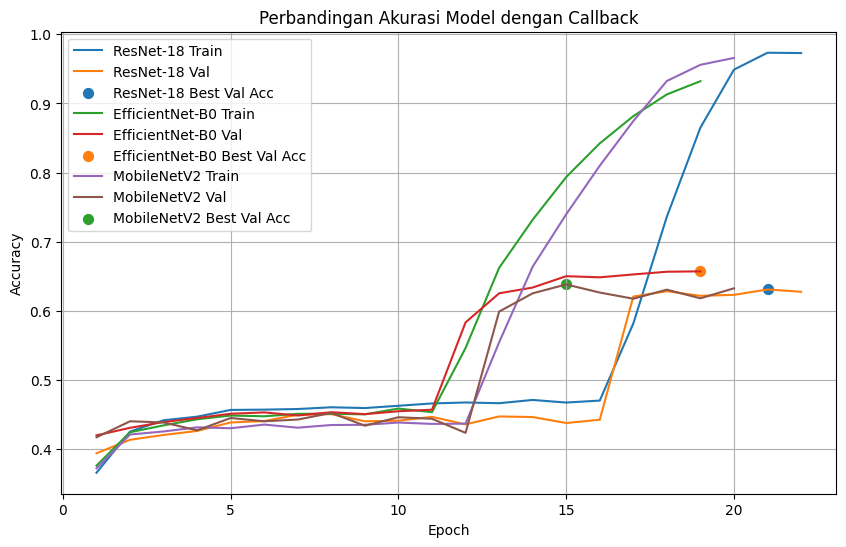

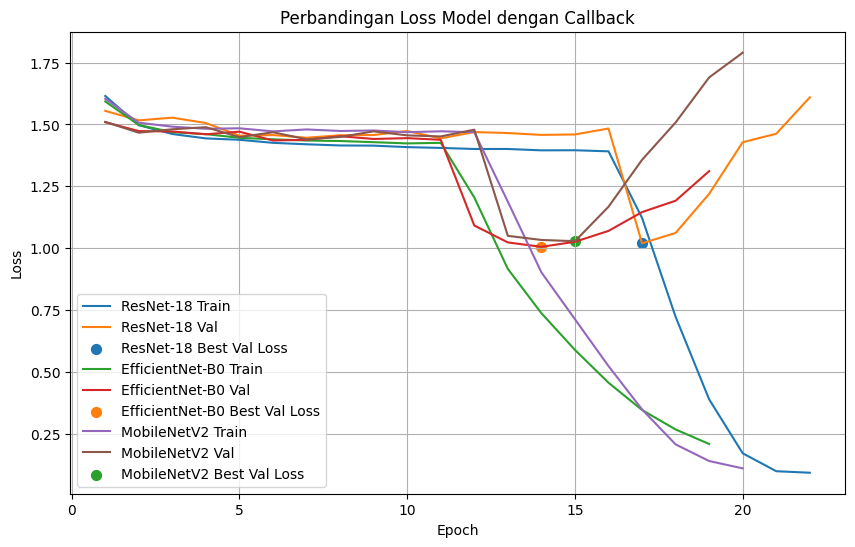

In [ ]:
plt.figure(figsize=(10, 6))
for model_name in results:
    train_accs = results[model_name]["train_accs"]
    val_accs = results[model_name]["val_accs"]
    epochs = range(1, len(train_accs) + 1)

    plt.plot(epochs, train_accs, label=f"{model_name} Train")
    plt.plot(epochs, val_accs, label=f"{model_name} Val")

    best_val_acc_epoch = val_accs.index(max(val_accs)) + 1
    best_val_acc = max(val_accs)

    plt.scatter(best_val_acc_epoch, best_val_acc, label=f"{model_name} Best Val Acc", s=50)

plt.title("Perbandingan Akurasi Model dengan Callback")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
for model_name in results:
    train_losses = results[model_name]["train_losses"]
    val_losses = results[model_name]["val_losses"]
    epochs = range(1, len(train_losses) + 1)

    plt.plot(epochs, train_losses, label=f"{model_name} Train")
    plt.plot(epochs, val_losses, label=f"{model_name} Val")

    best_val_loss_epoch = val_losses.index(min(val_losses)) + 1
    best_val_loss = min(val_losses)

    plt.scatter(best_val_loss_epoch, best_val_loss, label=f"{model_name} Best Val Loss", s=50)

plt.title("Perbandingan Loss Model dengan Callback")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()